<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Про датасет

https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

Датасет содержит 2000 записей о характеристиках мобильных телефонов.

Целевая переменная price_range — ценовая категория (0 = низкая, 1 = средняя, 2 = высокая, 3 = очень высокая).

# Постановка задачи

Целью работы является построение модели машинного обучения, которая по характеристикам смартфона будет предсказывать его ценовую категорию (0, 1, 2 или 3). Это задача многоклассовой классификации

# Загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
df = pd.read_csv("train.csv")

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Последний столбец price_range — это целевая переменная.

Она показывает ценовую категорию смартфона:

0 — низкая цена (бюджетный сегмент)

1 — средняя цена

2 — высокая цена

3 — очень высокая цена (премиум)

price_range — это переменная, которую в дальнейшем необходимо будет предсказывать, используя характеристики смартфона.

Признаки смартфона (остальные столбцы):

battery_power — ёмкость аккумулятора (мАч)

blue — наличие Bluetooth (1 — есть, 0 — нет)

clock_speed — тактовая частота процессора (ГГц)

dual_sim — поддержка двух SIM-карт (1 — есть, 0 — нет)

fc — разрешение фронтальной камеры (мегапиксели)

four_g — поддержка 4G (1 — есть, 0 — нет)

int_memory — объём встроенной памяти (ГБ)

m_dep — толщина корпуса (см)

mobile_wt — вес смартфона (граммы)

n_cores — количество ядер процессора

pc — разрешение основной камеры (мегапиксели)

px_height — высота экрана в пикселях

px_width — ширина экрана в пикселях

ram — объём оперативной памяти (МБ)

sc_h — высота экрана (см)

sc_w — ширина экрана (см)

talk_time — время работы в режиме разговора (часы)

three_g — поддержка 3G (1 — есть, 0 — нет)

touch_screen — наличие сенсорного экрана (1 — есть, 0 — нет)

wifi — наличие Wi‑Fi (1 — есть, 0 — нет)

# Анализ целевой переменной
Видим что классы полностью сбалансированны, по 500 объектов в каждом

In [40]:
# Распределение ценовых категорий
print(df['price_range'].value_counts())
print("Доли:")
print(df['price_range'].value_counts(normalize=True))

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64
Доли:
price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


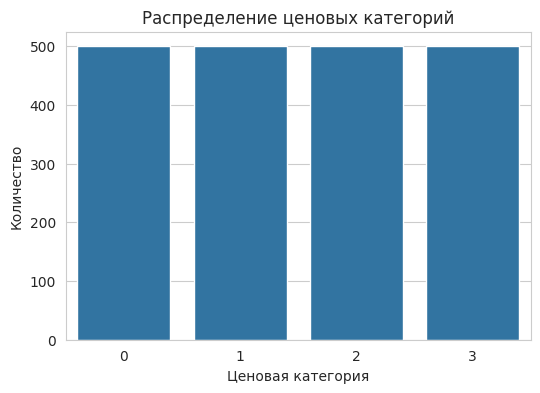

In [41]:
# Визуализация
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='price_range')
plt.title('Распределение ценовых категорий')
plt.xlabel('Ценовая категория')
plt.ylabel('Количество')
plt.show()

# Корреляционный анализ
Наиболее сильно с ценой коррелируют ram (0.92), battery_power (0.20), px_height (0.15) и px_width (0.14).

In [42]:
# Корреляция всех признаков с целевой переменной
corr = df.corr()['price_range'].sort_values(ascending=False)
print("Корреляция с ценовой категорией:")
print(corr)

Корреляция с ценовой категорией:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


# Анализ распределений признаков
С ростом цены RAM значительно увеличивается. Батарея, разрешение экрана тоже в среднем выше у дорогих моделей.

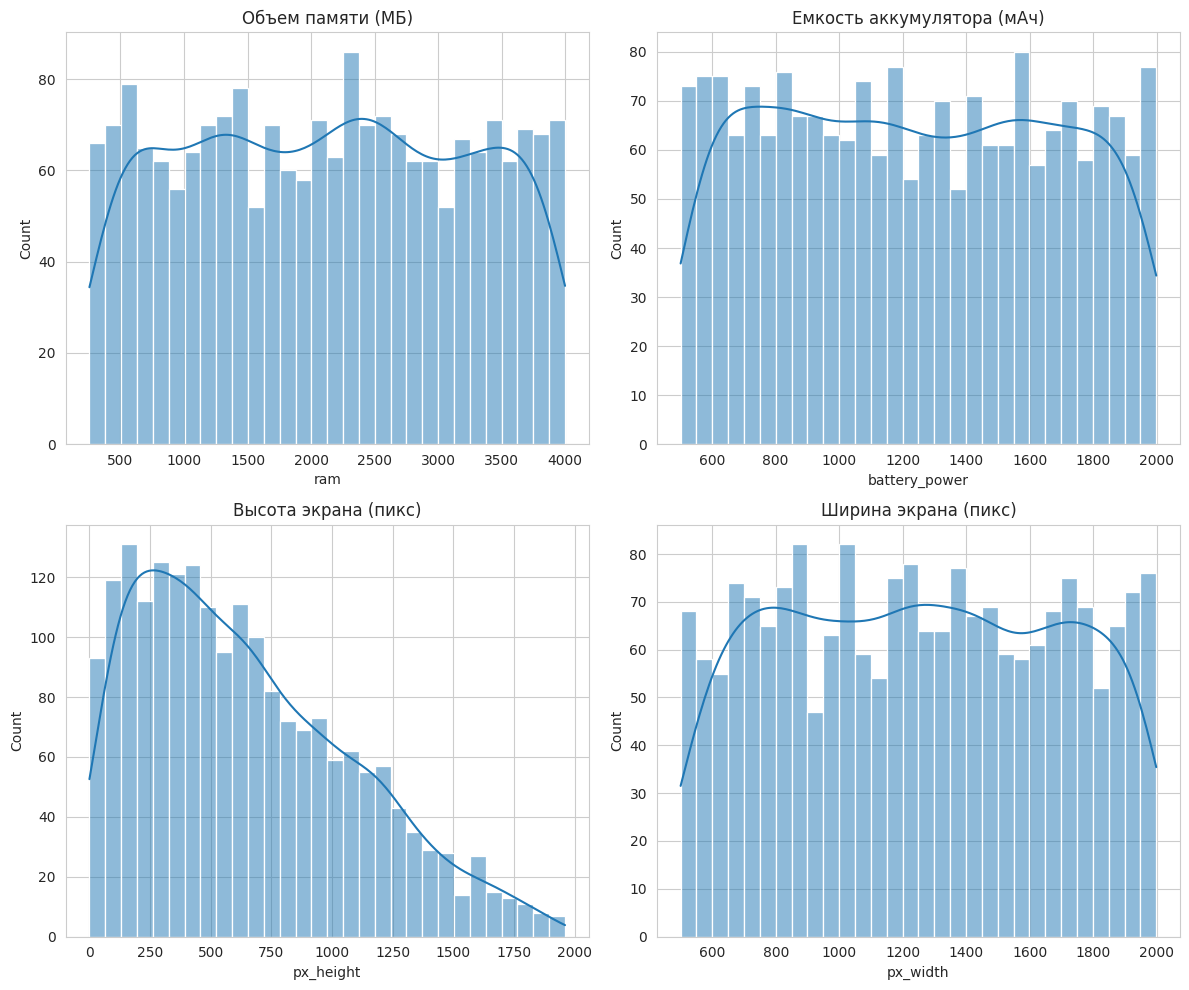

In [8]:
# Гистограммы для ключевых признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=df, x='ram', bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Объем памяти (МБ)')

sns.histplot(data=df, x='battery_power', bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Емкость аккумулятора (мАч)')

sns.histplot(data=df, x='px_height', bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Высота экрана (пикс)')

sns.histplot(data=df, x='px_width', bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title('Ширина экрана (пикс)')

plt.tight_layout()
plt.show()

# Анализ бинарных признаков
Поддержка 4G и Wi-Fi значительно чаще встречается в дорогих моделях. Bluetooth, dual SIM, сенсорный экран распределены более равномерно.

In [5]:
binary_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
for col in binary_cols:
    print(f"\n{col}:")
    print(df.groupby('price_range')[col].value_counts(normalize=True).unstack())


blue:
blue             0      1
price_range              
0            0.514  0.486
1            0.510  0.490
2            0.514  0.486
3            0.482  0.518

dual_sim:
dual_sim         0      1
price_range              
0            0.500  0.500
1            0.490  0.510
2            0.502  0.498
3            0.470  0.530

four_g:
four_g           0      1
price_range              
0            0.482  0.518
1            0.476  0.524
2            0.506  0.494
3            0.450  0.550

three_g:
three_g          0      1
price_range              
0            0.254  0.746
1            0.244  0.756
2            0.226  0.774
3            0.230  0.770

touch_screen:
touch_screen      0      1
price_range               
0             0.476  0.524
1             0.478  0.522
2             0.530  0.470
3             0.504  0.496

wifi:
wifi             0      1
price_range              
0            0.504  0.496
1            0.496  0.504
2            0.496  0.504
3            0.476  0.524

# Проверка выбросов
Выбросы присутствуют, но их немного. Для деревьев они не страшны, для линейных моделей можно применить масштабирование.

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('price_range')
outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_summary[col] = len(outliers)
print("Количество выбросов по признакам:")
print(pd.Series(outliers_summary).sort_values(ascending=False))

Количество выбросов по признакам:
three_g          477
fc                18
px_height          2
battery_power      0
dual_sim           0
clock_speed        0
blue               0
int_memory         0
m_dep              0
mobile_wt          0
n_cores            0
four_g             0
pc                 0
px_width           0
sc_h               0
ram                0
sc_w               0
talk_time          0
touch_screen       0
wifi               0
dtype: int64


# Пример создания нового признака

In [7]:
# Соотношение сторон экрана (aspect ratio)
df['aspect_ratio'] = df['px_height'] / df['px_width']
print("Корреляция aspect_ratio с price_range:", df['aspect_ratio'].corr(df['price_range']))

Корреляция aspect_ratio с price_range: 0.0556886734783427


# Выводы по EDA
1.Данные чистые, пропусков нет, классы сбалансированы.

2.Наиболее важный признак — ram (корреляция 0.92).

3.С ростом цены увеличиваются RAM, батарея, разрешение экрана, поддержка 4G и Wi-Fi.

4.Выбросы присутствуют, но не требуют обязательной обработки.

5.Для линейных моделей потребуется масштабирование признаков, для деревьев — нет.

# Выбор моделей и метрик
**Модели:**

Логистическая регрессия (baseline)

Случайный лес (Random Forest)

Градиентный бустинг (XGBoost)

**Метрики:**

Accuracy (общая точность)

Precision, Recall, F1-score (макро-усреднение, так как классы сбалансированы)

Confusion matrix (матрица ошибок)